In [1]:
import pandas as pd
from glob import glob

import arcgis
from arcgis.features import SpatialDataFrame
from arcgis.features.use_proximity import find_nearest

In [2]:
gis = GIS("https://geosaurus.maps.arcgis.com/", "rsingh_geosaurus", "@123")

## Places with confirmed Zika infections

Uses CDC Epidemic Prediction Initiative's repository of publicly available Zika data - https://github.com/cdcepi/zika

In [3]:
root = r'c:/xc/github/zika' 
location_files = glob(root +'/*/*Places.csv')

In [4]:
locations = pd.concat([pd.read_csv(x, encoding="ISO-8859-1")
                       for x in location_files], axis=0).reset_index(drop=True)

In [5]:
locations.head(1)

,alt_name1,alt_name2,city,country,district_county_municipality,location,location_type,state_province
0,Buenos Aires,BUENOS AIRES,NaN,Argentina,NaN,Argentina-Buenos_Aires,province,Buenos Aires


In [6]:
# clean up
locations.fillna('', inplace=True)
locations['country'] = locations.country.str.replace('_', ' ')

### Create address column

In [7]:
def get_address(location):
    addr_parts = location.split('-')
    addr = addr_parts[-1].replace('_', ' ')
    for part in addr_parts[-2::-1]:
        addr += ', ' + part.replace('_', ' ')
    return addr

In [8]:
locations['address'] = locations['location'].apply(get_address)

In [9]:
locations.head(1)

,alt_name1,alt_name2,city,country,district_county_municipality,location,location_type,state_province,address
0,Buenos Aires,BUENOS AIRES,,Argentina,,Argentina-Buenos_Aires,province,Buenos Aires,"Buenos Aires, Argentina"


In [59]:
locations[locations.country == 'Colombia']

,alt_name1,alt_name2,city,country,district_county_municipality,location,location_type,state_province,address,SHAPE
57,,,,Colombia,,Colombia,country,,Colombia,"{'y': 3.906097020000061, 'x': -73.07422810899999}"
58,5000,,,Colombia,Unknown,Colombia-Antioquia-Unknown,municipality,Antioquia,"Unknown, Antioquia, Colombia","{'y': 6.699277149000068, 'x': -75.50058499999994}"
59,5001,,,Colombia,Medellin,Colombia-Antioquia-Medellin,municipality,Antioquia,"Medellin, Antioquia, Colombia","{'y': 6.245890000000031, 'x': -75.57456999999994}"
60,5002,,,Colombia,Abejorral,Colombia-Antioquia-Abejorral,municipality,Antioquia,"Abejorral, Antioquia, Colombia","{'y': 5.789510000000064, 'x': -75.42728999999997}"
61,5004,,,Colombia,Abriaqui,Colombia-Antioquia-Abriaqui,municipality,Antioquia,"Abriaqui, Antioquia, Colombia","{'y': 6.632450000000063, 'x': -76.06434999999993}"
62,5021,,,Colombia,Alejandria,Colombia-Antioquia-Alejandria,municipality,Antioquia,"Alejandria, Antioquia, Colombia","{'y': 6.3776600000000485, 'x': -75.14113999999..."
63,5030,,,Colombia,Amaga,Colombia-Antioquia-Amaga,municipality,Antioquia,"Amaga, Antioquia, Colombia","{'y': 6.039670000000058, 'x': -75.70287999999994}"
64,5031,,,Colombia,Amalfi,Colombia-Antioquia-Amalfi,municipality,Antioquia,"Amalfi, Antioquia, Colombia","{'y': 6.907800000000066, 'x': -75.07402999999994}"
65,5034,,,Colombia,Andes,Colombia-Antioquia-Andes,municipality,Antioquia,"Andes, Antioquia, Colombia","{'y': 5.6562900000000695, 'x': -75.87817999999..."
66,5036,,,Colombia,Angelopolis,Colombia-Antioquia-Angelopolis,municipality,Antioquia,"Angelopolis, Antioquia, Colombia","{'y': 6.111360000000047, 'x': -75.71022999999997}"


### Create spatial dataframe

Create a spatially enabled dataframe, save it as a shapefile, and also import it into the GIS

In [10]:
spdf = SpatialDataFrame.from_df(locations)

In [11]:
spdf.sr = arcgis.geometry.SpatialReference(wkid=4326)

In [12]:
spdf.head()

,alt_name1,alt_name2,city,country,district_county_municipality,location,location_type,state_province,address,SHAPE
0,Buenos Aires,BUENOS AIRES,,Argentina,,Argentina-Buenos_Aires,province,Buenos Aires,"Buenos Aires, Argentina","{'y': -34.60848999999996, 'x': -58.37343999999..."
1,CABA,CABA,,Argentina,,Argentina-CABA,province,CABA,"CABA, Argentina","{'y': -34.60848999999996, 'x': -58.37343999999..."
2,Cordoba,CORDOBA,,Argentina,,Argentina-Cordoba,province,Cordoba,"Cordoba, Argentina","{'y': -31.407179999999983, 'x': -64.1857099999..."
3,Entre Rios,ENTRE RIOS,,Argentina,,Argentina-Entre_Rios,province,Entre Rios,"Entre Rios, Argentina","{'y': -32.06557803299995, 'x': -59.19547293199..."
4,Santa Fe,SANTA FE,,Argentina,,Argentina-Santa_Fe,province,Santa Fe,"Santa Fe, Argentina","{'y': -31.636649999999975, 'x': -60.7120299999..."


In [18]:
spdf.to_featureclass(out_location=root + r"\zika.gdb",
                          out_name="zika_locations")

'c:\\xc\\GitHub\\zika\\zika.gdb\\zika_locations'

In [13]:
zika_loc = gis.content.import_data(spdf, title='Places with Zika')

In [14]:
zika_loc

<Item title:"Places with Zika" type:Feature Layer Collection owner:rsingh_geosaurus>

In [17]:
zikalyr = zika_loc.layers[0]

### Map locations of zika infections

In [60]:
m = gis.map('USA')
m

In [61]:
m.add_layer(zika_loc)

## Airports

<Item title:"World Airport Locations" type:Feature Layer Collection owner:garycjohnsonDP>
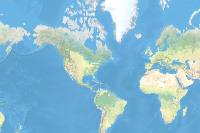

In [19]:
airports = gis.content.search('title: World Airport Locations owner:garycjohnsonDP', 'Feature Layer', outside_org=True)[0]
airports

In [20]:
airportlyr = airports.layers[0]

In [27]:
airportsdf = SpatialDataFrame.from_layer(airportlyr)

In [29]:
country = 'United States'

In [64]:
zikalyr.filter = "Country LIKE '%Colombia%'"

In [75]:
zikadf = zikalyr.query("Country = 'Colombia'").df

In [76]:
zikadf

,OBJECTID,address,alt_name1,alt_name2,city,country,district_county_municipality,location,location_type,state_province,SHAPE
0,58,Colombia,,,,Colombia,,Colombia,country,,"{'y': 435161.9477299576, 'x': -8134585.863205397}"
1,59,"Unknown, Antioquia, Colombia",5000,,,Colombia,Unknown,Colombia-Antioquia-Unknown,municipality,Antioquia,"{'y': 747465.2067389206, 'x': -8404686.676794263}"
2,60,"Medellin, Antioquia, Colombia",5001,,,Colombia,Medellin,Colombia-Antioquia-Medellin,municipality,Antioquia,"{'y': 696670.474939503, 'x': -8412922.649320602}"
3,61,"Abejorral, Antioquia, Colombia",5002,,,Colombia,Abejorral,Colombia-Antioquia-Abejorral,municipality,Antioquia,"{'y': 645584.843963891, 'x': -8396527.514716573}"
4,62,"Abriaqui, Antioquia, Colombia",5004,,,Colombia,Abriaqui,Colombia-Antioquia-Abriaqui,municipality,Antioquia,"{'y': 739975.4109752186, 'x': -8467444.70952133}"
5,63,"Alejandria, Antioquia, Colombia",5021,,,Colombia,Alejandria,Colombia-Antioquia-Alejandria,municipality,Antioquia,"{'y': 711428.505084108, 'x': -8364673.442426074}"
6,64,"Amaga, Antioquia, Colombia",5030,,,Colombia,Amaga,Colombia-Antioquia-Amaga,municipality,Antioquia,"{'y': 673581.5879782626, 'x': -8427206.053184286}"
7,65,"Amalfi, Antioquia, Colombia",5031,,,Colombia,Amalfi,Colombia-Antioquia-Amalfi,municipality,Antioquia,"{'y': 770842.4958503254, 'x': -8357202.791398937}"
8,66,"Andes, Antioquia, Colombia",5034,,,Colombia,Andes,Colombia-Antioquia-Andes,municipality,Antioquia,"{'y': 630680.5720360383, 'x': -8446720.359920355}"
9,67,"Angelopolis, Antioquia, Colombia",5036,,,Colombia,Angelopolis,Colombia-Antioquia-Angelopolis,municipality,Antioquia,"{'y': 681607.1603216031, 'x': -8428024.25144162}"


In [83]:
locations[locations.country == 'Colombia']

,alt_name1,alt_name2,city,country,district_county_municipality,location,location_type,state_province,address,SHAPE
57,,,,Colombia,,Colombia,country,,Colombia,"{'y': 3.906097020000061, 'x': -73.07422810899999}"
58,5000,,,Colombia,Unknown,Colombia-Antioquia-Unknown,municipality,Antioquia,"Unknown, Antioquia, Colombia","{'y': 6.699277149000068, 'x': -75.50058499999994}"
59,5001,,,Colombia,Medellin,Colombia-Antioquia-Medellin,municipality,Antioquia,"Medellin, Antioquia, Colombia","{'y': 6.245890000000031, 'x': -75.57456999999994}"
60,5002,,,Colombia,Abejorral,Colombia-Antioquia-Abejorral,municipality,Antioquia,"Abejorral, Antioquia, Colombia","{'y': 5.789510000000064, 'x': -75.42728999999997}"
61,5004,,,Colombia,Abriaqui,Colombia-Antioquia-Abriaqui,municipality,Antioquia,"Abriaqui, Antioquia, Colombia","{'y': 6.632450000000063, 'x': -76.06434999999993}"
62,5021,,,Colombia,Alejandria,Colombia-Antioquia-Alejandria,municipality,Antioquia,"Alejandria, Antioquia, Colombia","{'y': 6.3776600000000485, 'x': -75.14113999999..."
63,5030,,,Colombia,Amaga,Colombia-Antioquia-Amaga,municipality,Antioquia,"Amaga, Antioquia, Colombia","{'y': 6.039670000000058, 'x': -75.70287999999994}"
64,5031,,,Colombia,Amalfi,Colombia-Antioquia-Amalfi,municipality,Antioquia,"Amalfi, Antioquia, Colombia","{'y': 6.907800000000066, 'x': -75.07402999999994}"
65,5034,,,Colombia,Andes,Colombia-Antioquia-Andes,municipality,Antioquia,"Andes, Antioquia, Colombia","{'y': 5.6562900000000695, 'x': -75.87817999999..."
66,5036,,,Colombia,Angelopolis,Colombia-Antioquia-Angelopolis,municipality,Antioquia,"Angelopolis, Antioquia, Colombia","{'y': 6.111360000000047, 'x': -75.71022999999997}"


In [93]:
from arcgis.features import FeatureCollection
features = FeatureCollection(zikadf[0:1].to_featureset().value).layer

In [113]:
f = zikadf[0:1].to_featureset().value#dict(features)
f

{'features': [{'attributes': {'OBJECTID': 58,
    'address': 'Colombia',
    'alt_name1': '',
    'alt_name2': '',
    'city': '',
    'country': 'Colombia',
    'district_county_municipality': '',
    'location': 'Colombia',
    'location_type': 'country',
    'state_province': ''},
   'geometry': {'x': -8134585.863205397, 'y': 435161.9477299576}}],
 'fields': [],
 'geometryType': 'esriGeometryPoint',
 'spatialReference': {"latestWkid": 3857, "wkid": 102100}}

In [114]:

f['fields'] = [
                 {
                    "alias":"OBJECTID",
                    "name":"OBJECTID",
                    "type":"esriFieldTypeOID",
                    "editable":False
                 },
                 {
                    "alias":"alt_name1",
                    "name":"alt_name1",
                    "length":50,
                    "type":"esriFieldTypeString",
                    "editable":True
                 },
                 {
                    "alias":"country",
                    "name":"country",
                    "type":"esriFieldTypeString",
                    "editable":True
                 },
                 {
                    "alias":"location",
                    "name":"location",
                    "length":255,
                    "type":"esriFieldTypeString",
                    "editable":True
                 },
                 {
                    "alias":"location_type",
                    "name":"location_type",
                    "type":"esriFieldTypeString",
                    "length":255,
                    "editable":True
                 }
              ]

f

{'features': [{'attributes': {'OBJECTID': 58,
    'address': 'Colombia',
    'alt_name1': '',
    'alt_name2': '',
    'city': '',
    'country': 'Colombia',
    'district_county_municipality': '',
    'location': 'Colombia',
    'location_type': 'country',
    'state_province': ''},
   'geometry': {'x': -8134585.863205397, 'y': 435161.9477299576}}],
 'fields': [{'alias': 'OBJECTID',
   'editable': False,
   'name': 'OBJECTID',
   'type': 'esriFieldTypeOID'},
  {'alias': 'alt_name1',
   'editable': True,
   'length': 50,
   'name': 'alt_name1',
   'type': 'esriFieldTypeString'},
  {'alias': 'country',
   'editable': True,
   'name': 'country',
   'type': 'esriFieldTypeString'},
  {'alias': 'location',
   'editable': True,
   'length': 255,
   'name': 'location',
   'type': 'esriFieldTypeString'},
  {'alias': 'location_type',
   'editable': True,
   'length': 255,
   'name': 'location_type',
   'type': 'esriFieldTypeString'}],
 'geometryType': 'esriGeometryPoint',
 'spatialReference': {

In [115]:
country = "Colombia"
airportlyr.filter = "Country = '{}'".format(country.upper())

nearest_airports = find_nearest(f, airportlyr, 'StraightLine', max_count=1)


In [116]:
ddd = nearest_airports['connecting_lines_layer'].query().df
ddd

,From_ID,From_alt_name1,From_country,From_location,From_location_type,NearRank,OID,To_Airport_Name,To_Altitude,To_City,...,To_LatNS,To_LatSS,To_Latitude,To_LongDD,To_LongEW,To_LongMM,To_LongSS,To_Longitude,Total_Miles,SHAPE
0,58,,Colombia,Colombia,country,1,1,VANGUARDIA,1394,VILLAVICENCIO,...,N,4,4.167778,73,U,36,49,-73.613611,41.242045,"{'paths': [[[-8134585.8632, 435161.9477000013]..."


In [117]:
ddd.columns

Index(['From_ID', 'From_alt_name1', 'From_country', 'From_location',
       'From_location_type', 'NearRank', 'OID', 'To_Airport_Name',
       'To_Altitude', 'To_City', 'To_Country', 'To_IATA', 'To_ICAO', 'To_ID',
       'To_LatDD', 'To_LatMM', 'To_LatNS', 'To_LatSS', 'To_Latitude',
       'To_LongDD', 'To_LongEW', 'To_LongMM', 'To_LongSS', 'To_Longitude',
       'Total_Miles', 'SHAPE'],
      dtype='object')

In [77]:
N = len(zikadf)

In [78]:
batch_size = 1000

In [81]:
for i in range(0, N, batch_size):
    start = i
    stop = i + batch_size if i + batch_size < N else N
    print('Processing from ' + str(start) + ' to ' + str(stop))

    subdf = zikadf[start:stop]
    #res = batch_geocode(list(df[start:stop][address_column]), geocoder=geocoder)

Processing from 0 to 1000
Processing from 1000 to 1226


In [82]:
subdf

,OBJECTID,address,alt_name1,alt_name2,city,country,district_county_municipality,location,location_type,state_province,SHAPE
1000,1058,"Flandes, Tolima, Colombia",73275,,,Colombia,Flandes,Colombia-Tolima-Flandes,municipality,Tolima,"{'y': 477135.61588559224, 'x': -8328342.100215..."
1001,1059,"Fresno, Tolima, Colombia",73283,,,Colombia,Fresno,Colombia-Tolima-Fresno,municipality,Tolima,"{'y': 574539.4594772104, 'x': -8353503.644719875}"
1002,1060,"Guamo, Tolima, Colombia",73319,,,Colombia,Guamo,Colombia-Tolima-Guamo,municipality,Tolima,"{'y': 448990.14265470114, 'x': -8345477.509433..."
1003,1061,"Herveo, Tolima, Colombia",73347,,,Colombia,Herveo,Colombia-Tolima-Herveo,municipality,Tolima,"{'y': 566245.383294207, 'x': -8368477.229426484}"
1004,1062,"Honda, Tolima, Colombia",73349,,,Colombia,Honda,Colombia-Tolima-Honda,municipality,Tolima,"{'y': 580502.7169403741, 'x': -8319668.085493261}"
1005,1063,"Icononzo, Tolima, Colombia",73352,,,Colombia,Icononzo,Colombia-Tolima-Icononzo,municipality,Tolima,"{'y': 465421.84269412566, 'x': -8296884.325312..."
1006,1064,"Lerida, Tolima, Colombia",73408,,,Colombia,Lerida,Colombia-Tolima-Lerida,municipality,Tolima,"{'y': 541584.4490332445, 'x': -8339015.412993136}"
1007,1065,"Libano, Tolima, Colombia",73411,,,Colombia,Libano,Colombia-Tolima-Libano,municipality,Tolima,"{'y': 548481.3064872824, 'x': -8356235.425023942}"
1008,1066,"Mariquita, Tolima, Colombia",73443,,,Colombia,Mariquita,Colombia-Tolima-Mariquita,municipality,Tolima,"{'y': 579533.5834415999, 'x': -8337045.058006096}"
1009,1067,"Melgar, Tolima, Colombia",73449,,,Colombia,Melgar,Colombia-Tolima-Melgar,municipality,Tolima,"{'y': 468626.3968583781, 'x': -8309207.392943417}"


In [126]:
locations.head(1)[['address', 'SHAPE']]

,address,SHAPE
0,"Buenos Aires, Argentina","{'y': -34.60848999999996, 'x': -58.37343999999..."


In [138]:
airportsdf[airportsdf.Latitude != 0.0]

,Airport_Name,Altitude,City,Country,FID,IATA,ICAO,LatDD,LatMM,LatNS,LatSS,Latitude,LongDD,LongEW,LongMM,LongSS,Longitude,SHAPE
1,MANU DAYAK,1657,AGADEZ,NIGER,21,AJY,DRZA,16,57,N,53,16.964722,7,E,59,49,7.996944,"{'y': 1916718.885773576, 'x': 890215.7834081782}"
2,DIFFA,994,DIFFA,NIGER,23,N/A,DRZF,13,22,N,22,13.372778,12,E,37,36,12.626667,"{'y': 1502353.5764905638, 'x': 1405594.1041207..."
4,SIDI AHMED AIR BASE,20,BIZERTE,TUNISIA,34,N/A,DTTB,37,14,N,43,37.245278,9,E,47,29,9.791389,"{'y': 4473350.71469677, 'x': 1089972.4252823966}"
5,BORDJ EL AMRI,110,BORDJ EL AMRI,TUNISIA,38,N/A,DTTI,36,43,N,16,36.721111,9,E,56,35,9.943056,"{'y': 4400304.238899176, 'x': 1106855.8814231495}"
11,DEURNE,39,ANTWERP,BELGIUM,57,ANR,EBAW,51,11,N,24,51.190000,4,E,27,46,4.462778,"{'y': 6654971.588511478, 'x': 496794.14977049694}"
12,BEAUVECHAIN,370,BEAUVECHAIN,BELGIUM,58,N/A,EBBE,50,45,N,31,50.758611,4,E,46,6,4.768333,"{'y': 6578705.3876143135, 'x': 530808.438562153}"
13,BRUSSELS NATL,184,BRUSSELS,BELGIUM,60,BRU,EBBR,50,54,N,8,50.902222,4,E,29,55,4.498611,"{'y': 6604016.156205902, 'x': 500783.0981534827}"
14,BRAASCHAAT,70,BRASSCHAAT,BELGIUM,61,N/A,EBBT,51,20,N,0,51.333333,4,E,30,0,4.500000,"{'y': 6680469.6894353945, 'x': 500937.70856973..."
15,BERTRIX JEHONVILLE,1514,BERTRIX,BELGIUM,62,N/A,EBBX,49,53,N,14,49.887222,5,E,13,43,5.228611,"{'y': 6426767.575719258, 'x': 582046.3264325724}"
16,BRUSSELS SOUTH,614,CHARLEROI,BELGIUM,63,CRL,EBCI,50,27,N,33,50.459167,4,E,27,13,4.453611,"{'y': 6526178.449335283, 'x': 495773.72106778534}"


In [136]:
airportsdf.head(100)[['City', 'Latitude', 'Longitude', 'IATA', 'ICAO', 'SHAPE']]

,City,Latitude,Longitude,IATA,ICAO,SHAPE
0,BILMA,0.000000,0.000000,N/A,DRRI,"{'y': -7.081154551613622e-10, 'x': 0}"
1,AGADEZ,16.964722,7.996944,AJY,DRZA,"{'y': 1916718.885773576, 'x': 890215.7834081782}"
2,DIFFA,13.372778,12.626667,N/A,DRZF,"{'y': 1502353.5764905638, 'x': 1405594.1041207..."
3,ARLIT,0.000000,0.000000,N/A,DRZL,"{'y': -7.081154551613622e-10, 'x': 0}"
4,BIZERTE,37.245278,9.791389,N/A,DTTB,"{'y': 4473350.71469677, 'x': 1089972.4252823966}"
5,BORDJ EL AMRI,36.721111,9.943056,N/A,DTTI,"{'y': 4400304.238899176, 'x': 1106855.8814231495}"
6,ATAKPAME,0.000000,0.000000,N/A,DXAK,"{'y': -7.081154551613622e-10, 'x': 0}"
7,BASSARI,0.000000,0.000000,N/A,DXBS,"{'y': -7.081154551613622e-10, 'x': 0}"
8,DAPANGO,0.000000,0.000000,N/A,DXDP,"{'y': -7.081154551613622e-10, 'x': 0}"
9,ANIE,0.000000,0.000000,N/A,DXKP,"{'y': -7.081154551613622e-10, 'x': 0}"


### Find Nearest Airports from Zika locations using Spatial Analysis

In [62]:
location_airport_df = pd.DataFrame()

for country in locations.country.unique():
    print('Finding nearest airports for locations in: ' + country)
   
    zikalyr.filter = "Country LIKE '%{}%'".format(country)
    airportlyr.filter = "Country = '{}'".format(country.upper())

    if country == 'United States':
        airportlyr.filter = "COUNTRY='USA' OR COUNTRY='PUERTO RICO'"
    try:
        nearest_airports = find_nearest(zikalyr, airportlyr, 'StraightLine', max_count=1)

        m.add_layer(nearest_airports['nearest_layer'])
        m.add_layer(nearest_airports['connecting_lines_layer'])

        nearestdf = nearest_airports['connecting_lines_layer'].query().df

        df = nearestdf[['From_ID', 'From_address', 'OID', 'To_Airport_Name', 'To_IATA', 'To_ICAO', 'To_ID', 'Total_Miles']]
        location_airport_df = location_airport_df.append(df, ignore_index=True)
    except: 
        print('Unable to find nearest airports for locations in: ' + country)
        

Finding nearest airports for locations in: Argentina
Finding nearest airports for locations in: Brazil
Finding nearest airports for locations in: Colombia


{"messageCode": "AO_100034", "message": "The number of features in a0d54f28 can not be greater than 1000.0.", "params": {"analysisLayer": "a0d54f28", "max": 1000.0}}
{"messageCode": "AO_100030", "message": "FindNearest failed."}
Failed to execute (FindNearest).
Failed.


Unable to find nearest airports for locations in: Colombia
Finding nearest airports for locations in: Dominican Republic
Finding nearest airports for locations in: Ecuador
Finding nearest airports for locations in: El Salvador
Finding nearest airports for locations in: France
Finding nearest airports for locations in: Guatemala
Finding nearest airports for locations in: Haiti
Finding nearest airports for locations in: Mexico
Finding nearest airports for locations in: Nicaragua
Finding nearest airports for locations in: Panama
Finding nearest airports for locations in: United States


In [118]:
len(location_airport_df)

636

In [34]:
zikalyr.filter = "Country LIKE '%{}%'".format(country)
airportlyr.filter = "Country = '{}'".format(country.upper())

if country == 'United States':
    airportlyr.filter = "COUNTRY='USA' OR COUNTRY='PUERTO RICO'"

In [35]:
nearest_airports_us = find_nearest(zikalyr, airportlyr, 'StraightLine', max_count=1)

In [36]:
nearest_airports_us['nearest_layer'].query().df

,Airport_Name,Altitude,City,Country,IATA,ICAO,LatDD,LatMM,LatNS,LatSS,Latitude,LongDD,LongEW,LongMM,LongSS,Longitude,OID,ORIG_FID,SHAPE
0,ESLER RGNL,112,ALEXANDRIA,USA,ESF,KESF,31,23,N,41,31.394722,92,U,17,44,-92.295556,1,2959,"{'y': 3684118.1373613253, 'x': -10274294.24736..."
1,FRESNO YOSEMITE INTERNATIONAL,336,FRESNO,USA,FAT,KFAT,36,46,N,34,36.776111,119,U,43,5,-119.718056,2,2971,"{'y': 4407945.34034127, 'x': -13326952.988156635}"
2,PAGE FLD,17,FORT MYERS,USA,FMY,KFMY,26,35,N,11,26.586389,81,U,51,47,-81.863056,3,2992,"{'y': 3071890.863482088, 'x': -9112953.659702417}"
3,GARDEN CITY RGNL,2890,GARDEN CITY,USA,GCK,KGCK,37,55,N,39,37.927500,100,U,43,27,-100.724167,4,3018,"{'y': 4569189.05089993, 'x': -11212562.947628502}"
4,GAINESVILLE RGNL,152,GAINESVILLE,USA,GNV,KGNV,29,41,N,24,29.690000,82,U,16,18,-82.271667,5,3031,"{'y': 3463764.1482950673, 'x': -9158440.040362..."
5,AUSTIN STRAUBEL INTERNATIONAL,695,GREEN BAY,USA,GRB,KGRB,44,29,N,6,44.485000,88,U,7,46,-88.129444,6,3033,"{'y': 5540806.402549282, 'x': -9810524.87903527}"
6,GRISSOM ARB,811,PERU,USA,GUS,KGUS,40,38,N,53,40.648056,86,U,9,7,-86.151944,7,3048,"{'y': 4960567.719389424, 'x': -9590390.585879453}"
7,HOBART MUNI,1564,HOBART,USA,HBR,KHBR,34,59,N,28,34.991111,99,U,3,4,-99.051111,8,3058,"{'y': 4162673.2449914664, 'x': -11026319.25128..."
8,HARTFORD BRAINARD,19,HARTFORD,USA,HFD,KHFD,41,44,N,10,41.736111,72,U,39,0,-72.650000,9,3060,"{'y': 5121531.7675348, 'x': -8087361.006089382}"
9,ROSCOMMON CO,1150,HOUGHTON LAKE,USA,HTL,KHTL,44,21,N,35,44.359722,84,U,40,16,-84.671111,10,3104,"{'y': 5521279.83392182, 'x': -9425544.973749707}"


In [37]:
nearestdf = nearest_airports_us['connecting_lines_layer'].query().df
nearestdf.columns

Index(['From_ID', 'From_address', 'From_alt_name1', 'From_alt_name2',
       'From_city', 'From_country', 'From_district_county_municipality',
       'From_location', 'From_location_type', 'From_state_province',
       'NearRank', 'OID', 'To_Airport_Name', 'To_Altitude', 'To_City',
       'To_Country', 'To_IATA', 'To_ICAO', 'To_ID', 'To_LatDD', 'To_LatMM',
       'To_LatNS', 'To_LatSS', 'To_Latitude', 'To_LongDD', 'To_LongEW',
       'To_LongMM', 'To_LongSS', 'To_Longitude', 'Total_Miles', 'SHAPE'],
      dtype='object')

In [49]:
loc_airport = nearestdf[['From_ID', 'From_address', 'OID', 'To_Airport_Name', 'To_IATA', 'To_ICAO', 'To_ID', 'Total_Miles']]

In [40]:
m.add_layer(nearest_airports_us['nearest_layer'])

In [41]:
m.add_layer(nearest_airports_us['connecting_lines_layer'])

In [63]:
location_airport_df

,From_ID,From_address,OID,To_Airport_Name,To_IATA,To_ICAO,To_ID,Total_Miles
0,1,"Buenos Aires, Argentina",1,AEROPARQUE JORGE NEWBERY,AEP,SABE,6002,4.153021
1,2,"CABA, Argentina",2,AEROPARQUE JORGE NEWBERY,AEP,SABE,6002,4.153021
2,3,"Cordoba, Argentina",3,AMBROSIO L V TARAVELLA,COR,SACO,6019,5.890400
3,4,"Entre Rios, Argentina",4,GUALEGUAYCHU,GHU,SAAG,5972,73.006540
4,5,"Santa Fe, Argentina",5,SAUCE VIEJO,SFN,SAAV,5998,7.804494
5,6,"Chaco, Argentina",6,TERMAL,N/A,SARS,7288,30.725603
6,7,"Corrientes, Argentina",7,CORRIENTES,CNQ,SARC,7212,5.145345
7,8,"Formosa, Argentina",8,FORMOSA,FMA,SARF,7230,3.537827
8,9,"Misiones, Argentina",9,CATARATAS DEL IGUAZU,IGR,SARI,7242,53.986738
9,10,"Catamarca, Argentina",10,CATAMARCA,CTC,SANC,7063,7.710147
